 Three questions I want the data to answer
1. How many Airbnb listings are in Manhattan?
2. How many listings are available all year?
3. How many hosts are called Eric?

 How many Airbnb listings are in Manhattan?

In [1]:
import pandas as pd

In [9]:
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv(r"C:\Users\Gyameah\NYCAIRBNB.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
manhattan_count = (df["neighbourhood_group"] == "Manhattan").sum()
print("Number of Airbnb listings in Manhattan:", manhattan_count)

Number of Airbnb listings in Manhattan: 21661


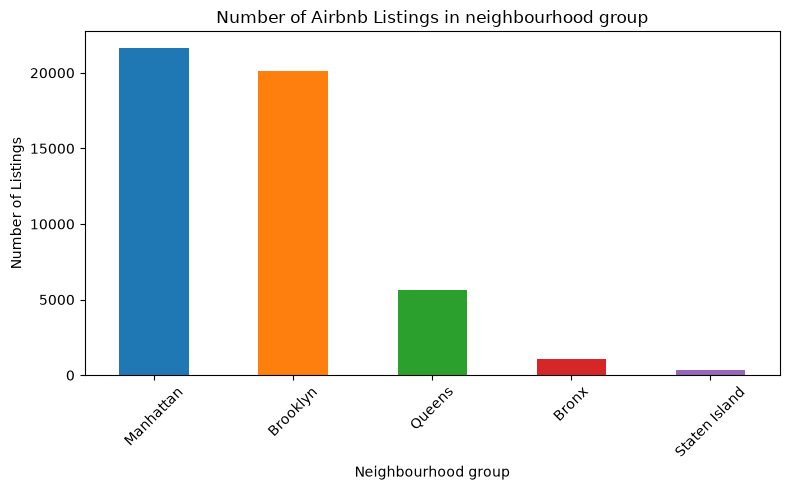

In [18]:
counts = df["neighbourhood_group"].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind="bar", color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
plt.title("Number of Airbnb Listings in neighbourhood group")
plt.xlabel("Neighbourhood group")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

How many listings are available all year?

In [12]:
operate_all_year = (df["availability_365"] == 365).sum()
print("The number of airbnbs that are available all year include:", operate_all_year)

The number of airbnbs that are available all year include: 1295


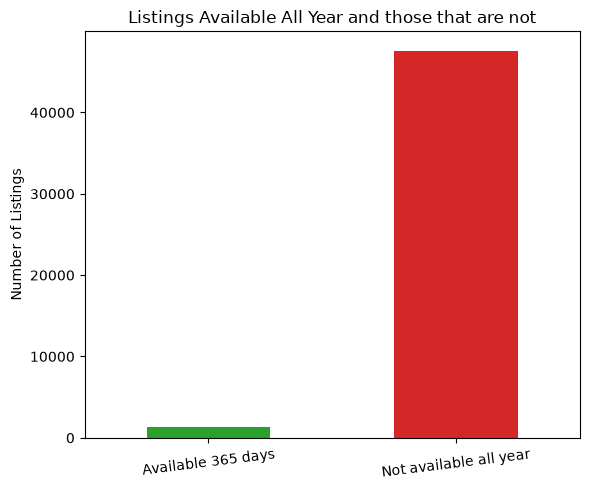

In [39]:
available_counts = pd.Series({
    "Available 365 days": operate_all_year,
    "Not available all year": len(df) - operate_all_year
})

plt.figure(figsize=(6, 5))
available_counts.plot(kind="bar", color=["#2ca02c", "#d62728"])
plt.title("Listings Available All Year and those that are not")
plt.ylabel("Number of Listings")
plt.xticks(rotation=7)
plt.tight_layout()
plt.show()

How many hosts are called Eric?

In [33]:
eric_hosts = df[df["host_name"] == "Eric"]
print(eric_hosts)
print("Number of listings with Eric as host_name:", len(eric_hosts))

             id                                               name    host_id  \
280       65813  Suite Sugar Hill, Harlem, Private Rm in Hosted...     321756   
399      126816                 Gorgeous Upper West Side Apartment     620288   
799      285492                Amazing 1 bedroom apt with NYC View    1486034   
1179     503529          HEART OF SOHO The Perfect One Bedroom Apt    2483293   
1184     504362                     1760 Sq ft Penthouse apartment    2487309   
...         ...                                                ...        ...   
43336  33590374            QUIET 1BR apartment CLOSE to EVERYTHING  127562833   
43378  33618626                      Highland Park 2 bedroom share    2099273   
45420  34741897  A+ 700 sqft. 1BR! Walk to Col. Cir., Central Park    3236741   
46112  35085643       Huge light & plant-filled Williamsburg condo    1040374   
46302  35189403                          Modern Cozy UES apartment   56341179   

      host_name neighbourho

host_name
Others    48764
Eric        131
Name: count, dtype: int64


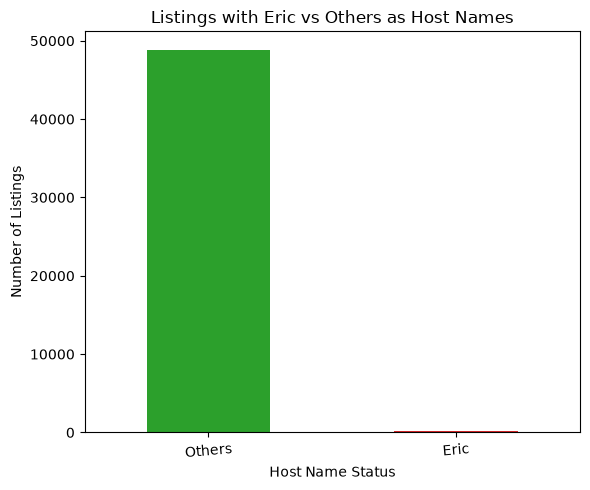

In [40]:
host_status = df["host_name"].apply(lambda x: "Eric" if x == "Eric" else "Others")
status_counts = host_status.value_counts()
print(status_counts)

plt.figure(figsize=(6, 5))
status_counts.plot(kind="bar", color=["#2ca02c", "#d62728"])
plt.title("Listings with Eric vs Others as Host Names")
plt.xlabel("Host Name Status")
plt.ylabel("Number of Listings")
plt.xticks(rotation=5)
plt.tight_layout()
plt.show()